# Total Energy from a Power Curve

**This notebook is self-contained; it recaps the trapezoid rule before applying it to real data.**

§3.4-3 differentiated the Dayton electricity series to find how fast demand was *changing*. This
notebook integrates the same data to answer the complementary question: **how much energy was actually
used?**

That pairing is the whole point of the unit. Power is a rate — energy per unit time. Differentiating a
total gives a rate; integrating a rate gives back a total. The same dataset, run through both halves
of calculus, answers two different questions.

## Learning objectives

- Integrate a real, unevenly-interesting time series with the trapezoid rule.
- Track **units** through the calculation, from megawatts to megawatt-hours.
- Compare totals across different time windows.

## Background

**Power** (megawatts, MW) is the *rate* at which energy is used. **Energy** (megawatt-hours, MWh) is
the total consumed. They are related by an integral:

$$\text{energy} = \int \text{power}\, dt$$

which is exactly the area under the power curve. Since readings are hourly, $\Delta t = 1$ hour, and
the trapezoid rule gives the answer directly in MWh.

Watch the units: MW × hours = MWh. Getting that wrong is the most common error in an applied integral,
and it is entirely avoidable by carrying the units through every step.

## This notebook covers

1. A day of demand, and the area under it.
2. Left/right/trapezoid on real data.
3. Scaling up: a month, a year.
4. The complement to §3.4-3, side by side.

**Prerequisites:** `U3-8_Integrals-3_DataPoints`

**Dataset:** `DAYTON_hourly.csv` — hourly megawatt load, from the shared dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. One day

Take a single day of hourly readings. The curve dips overnight and peaks in the evening. The **area**
under it is the total energy that region consumed that day.

In [2]:
power = pd.read_csv(helpers.data('Hourly Energy Consumption/DAYTON_hourly.csv'),
                    parse_dates=['Datetime'], index_col='Datetime').sort_index()
mw = power['DAYTON_MW']

day = mw['2015-01-14 00:00':'2015-01-14 23:00']
hours = np.arange(len(day))          # hours since midnight
values = day.values

print(f"{len(day)} hourly readings on {day.index[0].date()}")
print(f"demand ranged from {values.min():,.0f} to {values.max():,.0f} MW")

24 hourly readings on 2015-01-14
demand ranged from 2,304 to 2,773 MW


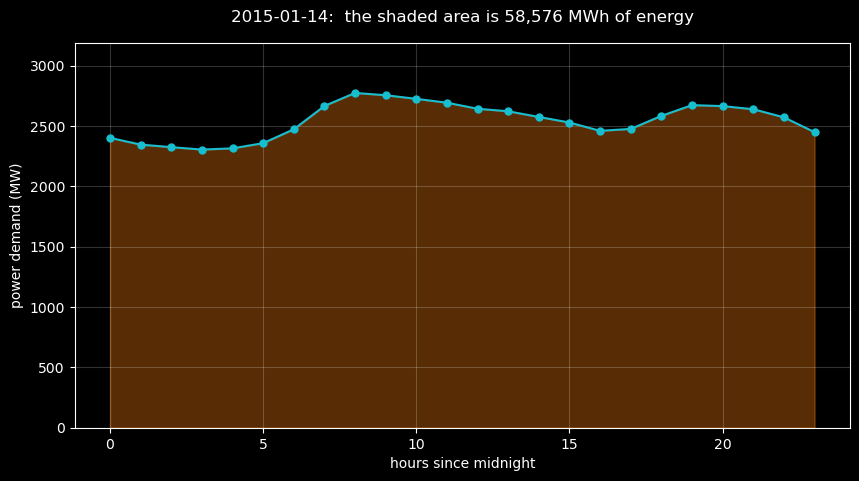

total energy that day = 58,575.5 MWh

sanity check: the average demand was 2,542 MW over 24 hours,
which would give roughly 58,458 MWh -- the same ballpark.


In [3]:
# note: np.trapz works on NumPy 1.x. It was renamed np.trapezoid in NumPy 2.0,
# so on a newer NumPy swap the name (the arguments are unchanged).
energy_day = np.trapz(values, hours)      # MW x hours = MWh

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(hours, values, 0, color="tab:orange", alpha=0.35, step=None)
ax.plot(hours, values, "o-", color="tab:cyan", markersize=5, lw=1.5)
ax.set_xlabel("hours since midnight")
ax.set_ylabel("power demand (MW)")
ax.set_ylim(0, values.max()*1.15)
ax.grid(alpha=0.2)
ax.set_title(f"{day.index[0].date()}:  the shaded area is {energy_day:,.0f} MWh of energy", pad=15)
plt.show()

print(f"total energy that day = {energy_day:,.1f} MWh")
print(f"\nsanity check: the average demand was {values.mean():,.0f} MW over 24 hours,")
print(f"which would give roughly {values.mean()*23:,.0f} MWh -- the same ballpark.")

## 2. The rules on real data

Left, right, and trapezoid on the same day. Because the curve returns to roughly where it started,
left and right nearly agree here — but that is a coincidence of this particular day, not a general fact.

In [4]:
dt = 1.0        # hours between readings
left = np.sum(values[:-1]) * dt
right = np.sum(values[1:]) * dt
trap = np.trapz(values, hours)

print(f"{'rule':<12} {'energy (MWh)':>16}")
print("-" * 30)
print(f"{'left':<12} {left:16,.1f}")
print(f"{'right':<12} {right:16,.1f}")
print(f"{'trapezoid':<12} {trap:16,.1f}")
print("-" * 30)
print(f"left and right differ by {abs(left-right):,.1f} MWh "
      f"({abs(left-right)/trap*100:.2f}% of the total)")
print("\nthey differ by exactly (last reading - first reading) * dt --")
print(f"here {values[-1]:,.0f} - {values[0]:,.0f} = {values[-1]-values[0]:,.0f} MWh")

rule             energy (MWh)
------------------------------
left                 58,552.0
right                58,599.0
trapezoid            58,575.5
------------------------------
left and right differ by 47.0 MWh (0.08% of the total)

they differ by exactly (last reading - first reading) * dt --
here 2,448 - 2,401 = 47 MWh


## 3. Scaling up

Nothing changes for longer windows — more points, same rule. A month and a year of totals, and the
seasonal pattern shows up clearly in the monthly figures.

In [5]:
def energy_of(series):
    hrs = np.arange(len(series))
    return np.trapz(series.values, hrs)

year = mw['2015']
monthly = year.resample('MS').apply(lambda s: energy_of(s) if len(s) > 1 else np.nan)

print(f"total energy in 2015 : {energy_of(year):,.0f} MWh")
print(f"average per day      : {energy_of(year)/365:,.0f} MWh\n")
print("by month (MWh):")
for date, val in monthly.items():
    print(f"   {date.strftime('%B'):<11} {val:12,.0f}")

total energy in 2015 : 17,431,001 MWh
average per day      : 47,756 MWh

by month (MWh):
   January        1,662,278
   February       1,578,396
   March          1,473,246
   April          1,245,600
   May            1,371,334
   June           1,483,099
   July           1,593,911
   August         1,550,438
   September      1,434,359
   October        1,315,628
   November       1,291,548
   December       1,410,738


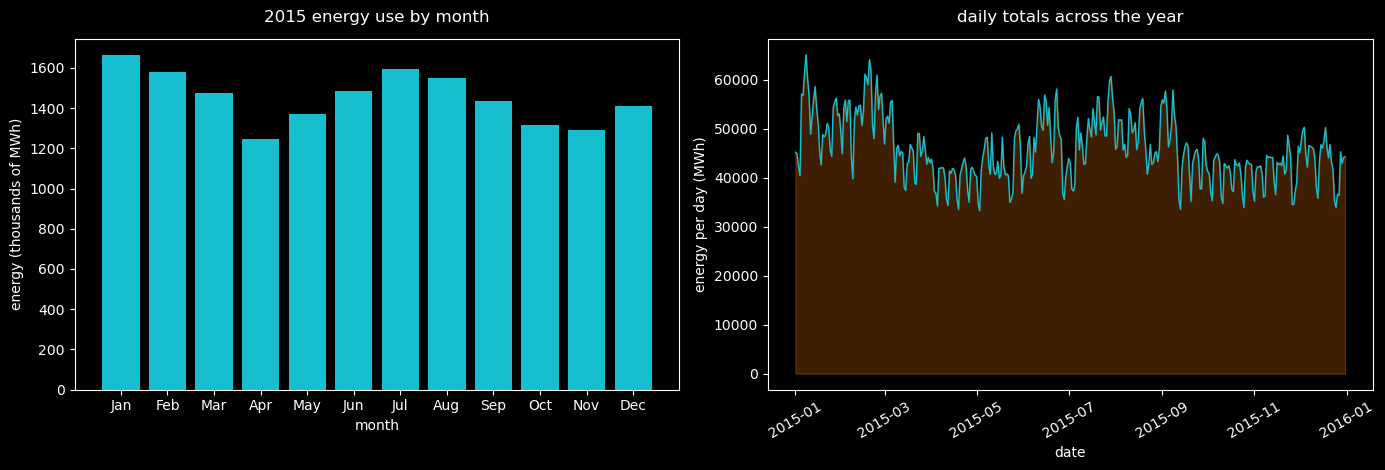

highest-demand month: January (1,662,278 MWh)
lowest-demand month : April (1,245,600 MWh)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].bar([d.strftime('%b') for d in monthly.index], monthly.values / 1e3,
            color="tab:cyan")
axes[0].set_ylabel("energy (thousands of MWh)")
axes[0].set_xlabel("month")
axes[0].set_title("2015 energy use by month", pad=12)

daily = year.resample('D').apply(lambda s: energy_of(s) if len(s) > 1 else np.nan)
axes[1].plot(daily.index, daily.values, color="tab:cyan", lw=1)
axes[1].fill_between(daily.index, daily.values, 0, color="tab:orange", alpha=0.25)
axes[1].set_ylabel("energy per day (MWh)")
axes[1].set_xlabel("date")
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title("daily totals across the year", pad=12)

plt.tight_layout()
plt.show()

print(f"highest-demand month: {monthly.idxmax().strftime('%B')} ({monthly.max():,.0f} MWh)")
print(f"lowest-demand month : {monthly.idxmin().strftime('%B')} ({monthly.min():,.0f} MWh)")

Summer peaks for air conditioning, with a secondary winter rise for heating — the same seasonal shape
§3.4-3 found in the *rate* of change, now visible in the *totals*.

## 4. The two halves, side by side

This is the unit in one figure. The same day of data, differentiated on the left and integrated on the
right:

- the **derivative** answers *how fast is demand changing right now?* — the ramping rate a grid
  operator has to match;
- the **integral** answers *how much energy has been used so far?* — the number that appears on a bill.

One dataset, two questions, two halves of calculus.

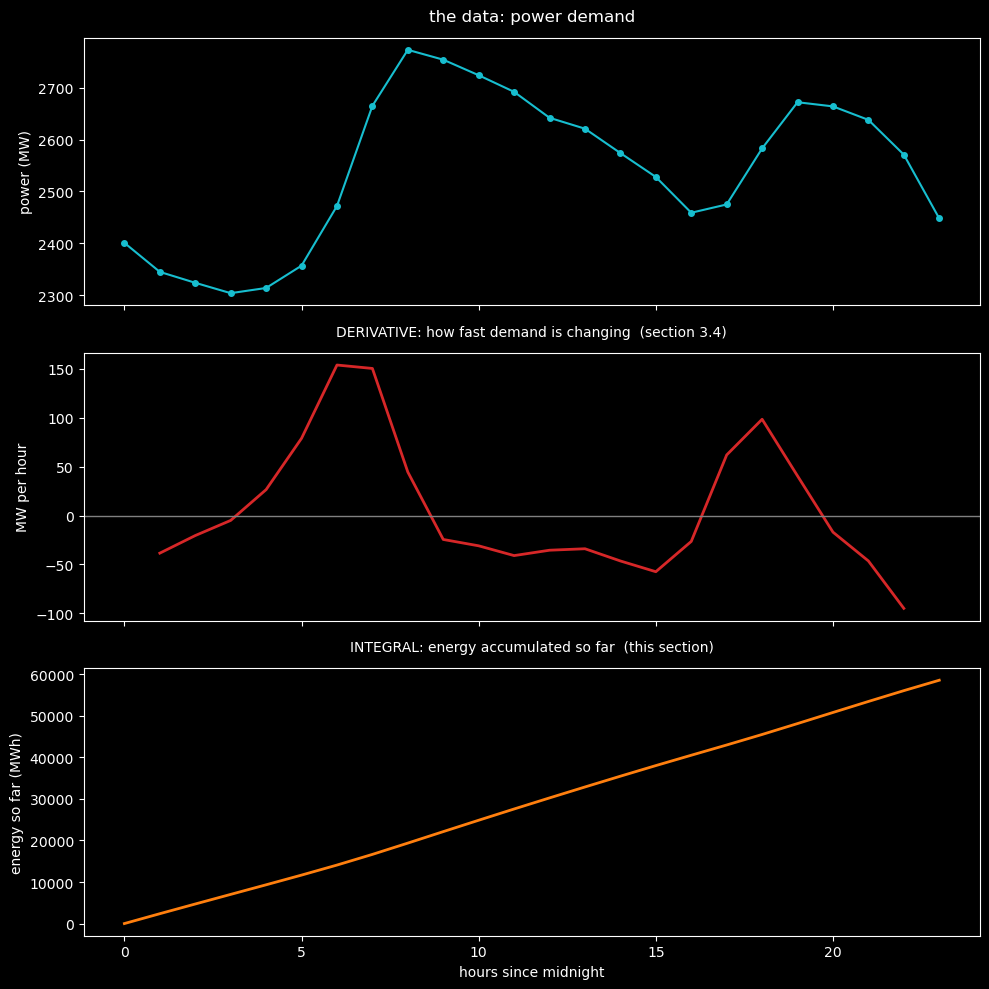

total for the day: 58,575.5 MWh
steepest ramp up : +154.0 MW/hour at hour 6


In [7]:
rate = (values[2:] - values[:-2]) / (2 * dt)                 # central difference, MW per hour
cumulative = np.concatenate([[0], np.cumsum((values[:-1] + values[1:]) / 2 * dt)])  # cumulative trapezoid

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(hours, values, "o-", color="tab:cyan", markersize=4)
axes[0].set_ylabel("power (MW)")
axes[0].set_title("the data: power demand", pad=12)

axes[1].plot(hours[1:-1], rate, color="tab:red", lw=2)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("MW per hour")
axes[1].set_title("DERIVATIVE: how fast demand is changing  (section 3.4)", pad=12, fontsize=10)

axes[2].plot(hours, cumulative, color="tab:orange", lw=2)
axes[2].set_ylabel("energy so far (MWh)")
axes[2].set_xlabel("hours since midnight")
axes[2].set_title("INTEGRAL: energy accumulated so far  (this section)", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

print(f"total for the day: {cumulative[-1]:,.1f} MWh")
print(f"steepest ramp up : {rate.max():+,.1f} MW/hour at hour {int(np.argmax(rate))+1}")

And the bottom panel is the **area-so-far** function from §3.8-2, built from real data. Its slope at
any point is the power reading directly above it — the Fundamental Theorem, visible in a utility
dataset.

## 5. Summary

- **Power is a rate; energy is its integral.** The area under a power curve is energy consumed.
- The trapezoid rule works directly on real hourly readings; `np.trapz` takes both $x$ and $y$ so
  uneven spacing is handled automatically.
- **Track the units.** MW × hours = MWh; the units of an integral are the product of the axes'.
- The same dataset answers two different questions depending on which half of calculus you apply.
- The cumulative-energy curve **is** the area-so-far function of §3.8-2, and its slope is the power —
  the Fundamental Theorem in real data.

Next: extending the idea to two dimensions — volume under a surface
(`U3-8_Integrals-5_2D`).